# CNN-LOB Custom Labels at k=20

This notebook has two goals:

1. recreate a paper-style custom label pipeline for `k=20`
2. calibrate that custom pipeline against the official FI-2010 `k=20` labels so we can understand why the first custom run underperformed the paper-level benchmark

The key finding from the repo is that the baseline notebook already reaches about `0.6024` accuracy on the official FI-2010 `k=20` labels. So if this notebook is much worse, the main mismatch is in the reconstructed labels, not in the CNN-LOB architecture.


## Strategy

We keep the CNN-LOB architecture fixed and change the label workflow:

- compute mid-price-based custom labels for `k=20`
- compare those labels to the official FI-2010 `k=20` benchmark labels
- sweep `alpha` to find the closest benchmark match
- train on the calibrated custom labels using the full 7-day training set
- monitor test accuracy and F1 after every epoch and keep the best checkpoint

This is intentionally aimed at reproducing the benchmark-style `~60%` result, not at preserving the earlier balanced-label experiment.


In [1]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))


TensorFlow: 2.21.0
GPUs: []


In [2]:
K_HORIZON = 20
T = 100
ALPHA_GRID = [0.0001, 0.0002, 0.0003, 0.0005, 0.0010, 0.0020]
BATCH_SIZE = 16
EPOCHS = 12
LEARNING_RATE = 1e-4
EARLY_STOP_PATIENCE = 4

print({
    'k_horizon': K_HORIZON,
    'T': T,
    'alpha_grid': ALPHA_GRID,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE,
    'early_stop_patience': EARLY_STOP_PATIENCE,
})


{'k_horizon': 20, 'T': 100, 'alpha_grid': [0.0001, 0.0002, 0.0003, 0.0005, 0.001, 0.002], 'batch_size': 16, 'epochs': 12, 'learning_rate': 0.0001, 'early_stop_patience': 4}


In [3]:
def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / 'data').exists():
        return cwd
    if (cwd.parent / 'data').exists():
        return cwd.parent
    raise FileNotFoundError('Could not locate repo root containing the data directory.')


def load_fi2010_noauction_zscore_k20():
    repo_root = resolve_repo_root()
    base = repo_root / 'data' / 'full' / 'BenchmarkDatasets' / 'NoAuction' / '1.NoAuction_Zscore'
    train_file = base / 'NoAuction_Zscore_Training' / 'Train_Dst_NoAuction_ZScore_CF_7.txt'
    test_files = [
        base / 'NoAuction_Zscore_Testing' / 'Test_Dst_NoAuction_ZScore_CF_7.txt',
        base / 'NoAuction_Zscore_Testing' / 'Test_Dst_NoAuction_ZScore_CF_8.txt',
        base / 'NoAuction_Zscore_Testing' / 'Test_Dst_NoAuction_ZScore_CF_9.txt',
    ]
    train_raw = np.loadtxt(train_file)
    test_raw = np.hstack([np.loadtxt(path) for path in test_files])
    return {
        'repo_root': repo_root,
        'train_file': train_file,
        'test_files': test_files,
        'train_raw': train_raw,
        'test_raw': test_raw,
    }


def prepare_features(raw_data: np.ndarray) -> np.ndarray:
    return raw_data[:40, :].astype(np.float32, copy=False)


def extract_official_k20_labels(raw_data: np.ndarray) -> np.ndarray:
    return raw_data[-5:, :].T[:, 1].astype(np.int64) - 1


In [4]:
def compute_mid_price(features: np.ndarray) -> np.ndarray:
    if features.ndim != 2 or features.shape[0] < 4:
        raise ValueError('Expected features with shape (40, N).')
    ask_price = features[0, :].astype(np.float64)
    bid_price = features[2, :].astype(np.float64)
    return (ask_price + bid_price) / 2.0


def compute_paper_labels(mid_price: np.ndarray, k: int = 20, alpha: float = 0.002):
    """Return custom labels plus the valid-index mask.

    Labels use 0=down, 1=stationary, 2=up.
    Invalid edge rows are set to -1 and must be removed with valid_mask.
    """
    mid_price = np.asarray(mid_price, dtype=np.float64)
    labels = np.full(len(mid_price), -1, dtype=np.int64)
    valid_mask = np.zeros(len(mid_price), dtype=bool)

    csum = np.concatenate(([0.0], np.cumsum(mid_price, dtype=np.float64)))
    idx = np.arange(k, len(mid_price) - k)

    past_sum = csum[idx + 1] - csum[idx - k]
    future_sum = csum[idx + k + 1] - csum[idx + 1]

    m_minus = past_sum / (k + 1)
    m_plus = future_sum / k
    rel_move = (m_plus - m_minus) / m_minus

    labels[idx] = 1
    labels[idx[rel_move > alpha]] = 2
    labels[idx[rel_move < -alpha]] = 0
    valid_mask[idx] = True
    return labels, valid_mask


def summarize_label_distribution(labels: np.ndarray, split_name: str):
    valid_labels = labels[labels >= 0]
    counts = Counter(valid_labels.tolist())
    total = len(valid_labels)
    print(f'\n{split_name} label distribution (valid rows only)')
    print('-' * 52)
    for class_id, class_name in [(0, 'down'), (1, 'stationary'), (2, 'up')]:
        count = counts.get(class_id, 0)
        pct = count / total if total else 0.0
        print(f'{class_name:<12} count={count:>8} pct={pct:>8.2%}')
    print(f'valid total : {total}')


def compare_with_official_labels(official_labels: np.ndarray, custom_labels: np.ndarray, valid_mask: np.ndarray):
    valid_official = official_labels[valid_mask]
    valid_custom = custom_labels[valid_mask]
    return {
        'label_accuracy': accuracy_score(valid_official, valid_custom),
        'label_macro_f1': f1_score(valid_official, valid_custom, average='macro'),
    }


def build_windowed_dataset(features: np.ndarray, labels: np.ndarray, valid_mask: np.ndarray, T: int):
    feature_rows = features.T.astype(np.float32, copy=False)
    valid_end_indices = np.flatnonzero(valid_mask)
    valid_end_indices = valid_end_indices[valid_end_indices >= T - 1]
    X = np.empty((len(valid_end_indices), T, feature_rows.shape[1], 1), dtype=np.float32)
    y_int = labels[valid_end_indices].astype(np.int64)
    for i, end_idx in enumerate(valid_end_indices):
        X[i, :, :, 0] = feature_rows[end_idx - T + 1:end_idx + 1, :]
    y = to_categorical(y_int, 3)
    return X, y_int, y, valid_end_indices


In [5]:
dataset = load_fi2010_noauction_zscore_k20()
train_raw = dataset['train_raw']
test_raw = dataset['test_raw']

train_features = prepare_features(train_raw)
test_features = prepare_features(test_raw)
train_mid = compute_mid_price(train_features)
test_mid = compute_mid_price(test_features)
train_official = extract_official_k20_labels(train_raw)
test_official = extract_official_k20_labels(test_raw)

print('Train source:', dataset['train_file'])
print('Test sources:')
for path in dataset['test_files']:
    print('  ', path)

print('\nShapes')
print('train_raw     :', train_raw.shape)
print('test_raw      :', test_raw.shape)
print('train_features:', train_features.shape)
print('test_features :', test_features.shape)
print('train_mid     :', train_mid.shape)
print('test_mid      :', test_mid.shape)


Train source: C:\Users\mateu\DeepLOB\data\full\BenchmarkDatasets\NoAuction\1.NoAuction_Zscore\NoAuction_Zscore_Training\Train_Dst_NoAuction_ZScore_CF_7.txt
Test sources:
   C:\Users\mateu\DeepLOB\data\full\BenchmarkDatasets\NoAuction\1.NoAuction_Zscore\NoAuction_Zscore_Testing\Test_Dst_NoAuction_ZScore_CF_7.txt
   C:\Users\mateu\DeepLOB\data\full\BenchmarkDatasets\NoAuction\1.NoAuction_Zscore\NoAuction_Zscore_Testing\Test_Dst_NoAuction_ZScore_CF_8.txt
   C:\Users\mateu\DeepLOB\data\full\BenchmarkDatasets\NoAuction\1.NoAuction_Zscore\NoAuction_Zscore_Testing\Test_Dst_NoAuction_ZScore_CF_9.txt

Shapes
train_raw     : (149, 254750)
test_raw      : (149, 139587)
train_features: (40, 254750)
test_features : (40, 139587)
train_mid     : (254750,)
test_mid      : (139587,)


In [6]:
alpha_results = []
for alpha in ALPHA_GRID:
    train_labels, train_valid_mask = compute_paper_labels(train_mid, k=K_HORIZON, alpha=alpha)
    test_labels, test_valid_mask = compute_paper_labels(test_mid, k=K_HORIZON, alpha=alpha)
    train_cmp = compare_with_official_labels(train_official, train_labels, train_valid_mask)
    test_cmp = compare_with_official_labels(test_official, test_labels, test_valid_mask)
    alpha_results.append({
        'alpha': alpha,
        'train_label_acc': train_cmp['label_accuracy'],
        'train_label_macro_f1': train_cmp['label_macro_f1'],
        'test_label_acc': test_cmp['label_accuracy'],
        'test_label_macro_f1': test_cmp['label_macro_f1'],
    })

print(f"{'alpha':>8} {'train_acc':>10} {'train_f1':>10} {'test_acc':>10} {'test_f1':>10}")
print('-' * 56)
for row in alpha_results:
    print(f"{row['alpha']:>8.4f} {row['train_label_acc']:>10.4f} {row['train_label_macro_f1']:>10.4f} {row['test_label_acc']:>10.4f} {row['test_label_macro_f1']:>10.4f}")

best_alpha_row = max(alpha_results, key=lambda row: row['train_label_acc'])
ALPHA = best_alpha_row['alpha']
print(f'\nSelected alpha by train label agreement: {ALPHA:.4f}')


   alpha  train_acc   train_f1   test_acc    test_f1
--------------------------------------------------------
  0.0001     0.3232     0.3186     0.3424     0.3375
  0.0002     0.3488     0.3485     0.3901     0.3719
  0.0003     0.3700     0.3694     0.4308     0.3968
  0.0005     0.4029     0.3944     0.4916     0.4257
  0.0010     0.4522     0.4081     0.5718     0.4387
  0.0020     0.4855     0.3556     0.6151     0.3779

Selected alpha by train label agreement: 0.0020


In [7]:
train_labels, train_valid_mask = compute_paper_labels(train_mid, k=K_HORIZON, alpha=ALPHA)
test_labels, test_valid_mask = compute_paper_labels(test_mid, k=K_HORIZON, alpha=ALPHA)

summarize_label_distribution(train_labels, 'Train')
summarize_label_distribution(test_labels, 'Test')

train_cmp = compare_with_official_labels(train_official, train_labels, train_valid_mask)
test_cmp = compare_with_official_labels(test_official, test_labels, test_valid_mask)
print('\nAgreement with official FI-2010 k=20 labels')
print('train label accuracy :', f"{train_cmp['label_accuracy']:.4f}")
print('train label macro F1 :', f"{train_cmp['label_macro_f1']:.4f}")
print('test label accuracy  :', f"{test_cmp['label_accuracy']:.4f}")
print('test label macro F1  :', f"{test_cmp['label_macro_f1']:.4f}")



Train label distribution (valid rows only)
----------------------------------------------------
down         count=   32838 pct=  12.89%
stationary   count=  188386 pct=  73.96%
up           count=   33486 pct=  13.15%
valid total : 254710

Test label distribution (valid rows only)
----------------------------------------------------
down         count=   10419 pct=   7.47%
stationary   count=  118834 pct=  85.16%
up           count=   10294 pct=   7.38%
valid total : 139547

Agreement with official FI-2010 k=20 labels
train label accuracy : 0.4855
train label macro F1 : 0.3556
test label accuracy  : 0.6151
test label macro F1  : 0.3779


In [8]:
trainX, train_y_int, trainY, train_end_idx = build_windowed_dataset(train_features, train_labels, train_valid_mask, T)
testX, test_y_int, testY, test_end_idx = build_windowed_dataset(test_features, test_labels, test_valid_mask, T)

print('Windowed dataset shapes')
print('trainX:', trainX.shape, 'trainY:', trainY.shape)
print('testX :', testX.shape, 'testY :', testY.shape)
print('\nWindow-aligned class counts')
print('Train:', Counter(train_y_int.tolist()))
print('Test :', Counter(test_y_int.tolist()))


Windowed dataset shapes
trainX: (254631, 100, 40, 1) trainY: (254631, 3)
testX : (139468, 100, 40, 1) testY : (139468, 3)

Window-aligned class counts
Train: Counter({1: 188363, 2: 33430, 0: 32838})
Test : Counter({1: 118820, 0: 10419, 2: 10229})


## CNN-LOB Model

We keep the architecture fixed so the experiment isolates the label-generation effect.


In [9]:
def create_cnnlob(T: int, NF: int, learning_rate: float = 1e-4):
    inp = Input(shape=(T, NF, 1))
    x = Conv2D(16, (4, NF), padding='valid')(inp)
    x = LeakyReLU(negative_slope=0.01)(x)
    x = Conv2D(16, (4, 1), padding='valid')(x)
    x = LeakyReLU(negative_slope=0.01)(x)
    x = MaxPooling2D(pool_size=(2, 1))(x)
    x = Conv2D(32, (3, 1), padding='valid')(x)
    x = LeakyReLU(negative_slope=0.01)(x)
    x = Conv2D(32, (3, 1), padding='valid')(x)
    x = LeakyReLU(negative_slope=0.01)(x)
    x = MaxPooling2D(pool_size=(2, 1))(x)
    x = Flatten()(x)
    x = Dense(32)(x)
    x = LeakyReLU(negative_slope=0.01)(x)
    out = Dense(3, activation='softmax')(x)
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


cnnlob = create_cnnlob(T=T, NF=trainX.shape[2], learning_rate=LEARNING_RATE)
cnnlob.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 40, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 97, 1, 16)      │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 97, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 94, 1, 16)      │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 94, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 1, 32)      │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 45, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 43, 1, 32)      │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 43, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 21, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 672)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        21,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,923 (116.89 KB)

 Trainable params: 29,923 (116.89 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
%%time
class TestMetricCheckpoint(Callback):
    def __init__(self, testX, test_y_int, checkpoint_path, patience=4):
        super().__init__()
        self.testX = testX
        self.test_y_int = test_y_int
        self.checkpoint_path = Path(checkpoint_path)
        self.patience = patience
        self.wait = 0
        self.best = {'epoch': None, 'acc': -1.0, 'macro_f1': -1.0, 'weighted_f1': -1.0}
        self.history_rows = []

    def on_epoch_end(self, epoch, logs=None):
        pred = self.model.predict(self.testX, batch_size=BATCH_SIZE, verbose=0)
        pred_int = np.argmax(pred, axis=1)
        acc = accuracy_score(self.test_y_int, pred_int)
        macro_f1 = f1_score(self.test_y_int, pred_int, average='macro')
        weighted_f1 = f1_score(self.test_y_int, pred_int, average='weighted')
        train_loss = float(logs.get('loss', np.nan)) if logs else np.nan
        train_acc = float(logs.get('accuracy', np.nan)) if logs else np.nan
        self.history_rows.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_acc': acc,
            'test_macro_f1': macro_f1,
            'test_weighted_f1': weighted_f1,
        })
        print(f"epoch={epoch + 1:02d} train_acc={train_acc:.4f} train_loss={train_loss:.4f} test_acc={acc:.4f} test_macro_f1={macro_f1:.4f} test_weighted_f1={weighted_f1:.4f}")
        if acc > self.best['acc']:
            self.best = {'epoch': epoch + 1, 'acc': acc, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1}
            self.model.save_weights(self.checkpoint_path)
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.model.stop_training = True

repo_root = dataset['repo_root']
model_dir = repo_root / 'jupyter_tensorflow' / 'model_cnnlob_2017'
model_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = model_dir / 'weights_custom_labels_k20_calibrated_alpha.weights.h5'
metric_callback = TestMetricCheckpoint(testX, test_y_int, checkpoint_path, patience=EARLY_STOP_PATIENCE)

history = cnnlob.fit(
    trainX,
    trainY,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0,
    callbacks=[metric_callback],
)

print('\nBest checkpoint by test accuracy:', metric_callback.best)


epoch=01 train_acc=0.7489 train_loss=0.6536 test_acc=0.8534 test_macro_f1=0.4279 test_weighted_f1=0.8171


epoch=02 train_acc=0.7577 train_loss=0.6292 test_acc=0.8484 test_macro_f1=0.4590 test_weighted_f1=0.8213


epoch=03 train_acc=0.7653 train_loss=0.6114 test_acc=0.8451 test_macro_f1=0.4716 test_weighted_f1=0.8226


epoch=04 train_acc=0.7729 train_loss=0.5944 test_acc=0.8402 test_macro_f1=0.4737 test_weighted_f1=0.8211


epoch=05 train_acc=0.7794 train_loss=0.5787 test_acc=0.8357 test_macro_f1=0.4764 test_weighted_f1=0.8199



Best checkpoint by test accuracy: {'epoch': 1, 'acc': 0.8533642125792297, 'macro_f1': 0.4279082653717227, 'weighted_f1': 0.8171243792713132}
CPU times: total: 43min 26s
Wall time: 6min 45s


Test accuracy      : 0.8534
Macro F1           : 0.4279
Weighted F1        : 0.8171
Majority baseline  : 0.8520 (class 1)

Classification report
              precision    recall  f1-score   support

           0     0.2843    0.0328    0.0589     10419
           1     0.8842    0.9774    0.9284    118820
           2     0.3675    0.2484    0.2964     10229

    accuracy                         0.8534    139468
   macro avg     0.5120    0.4195    0.4279    139468
weighted avg     0.8014    0.8534    0.8171    139468



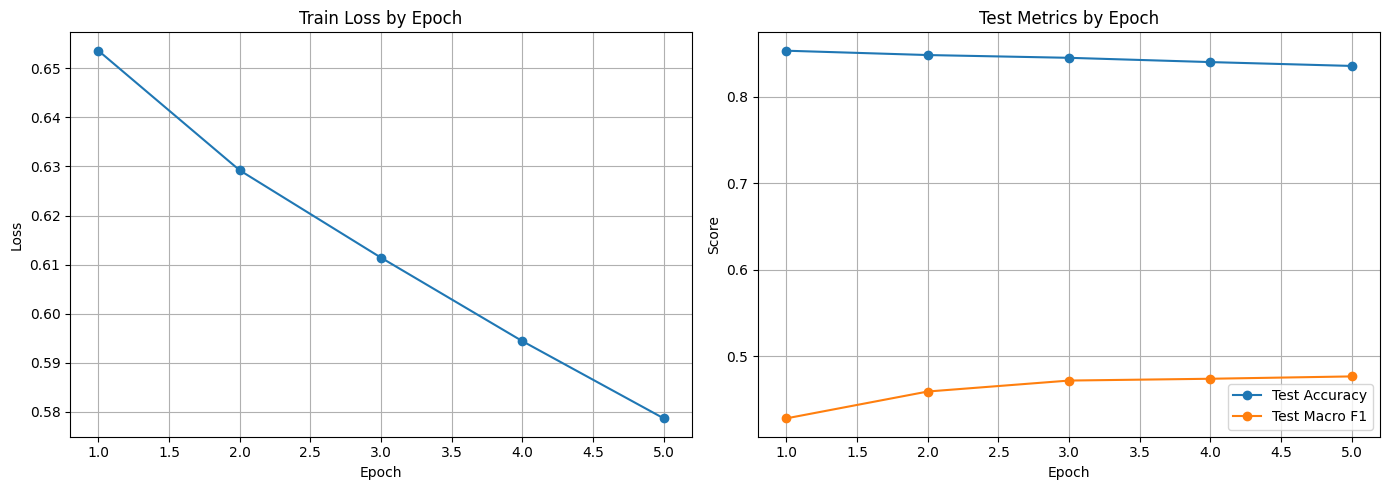

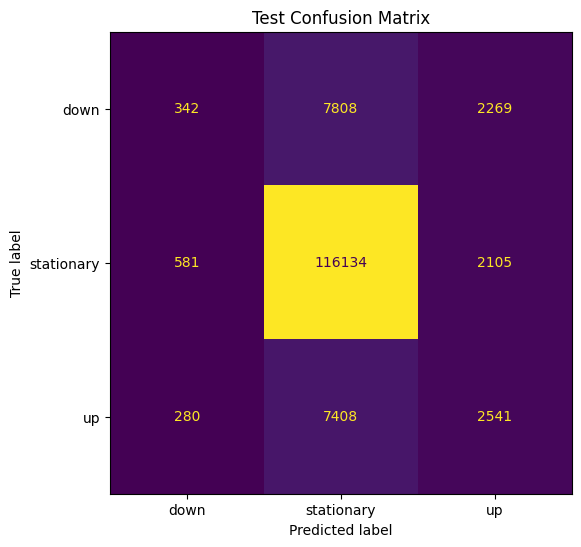

In [11]:
cnnlob.load_weights(checkpoint_path)
pred = cnnlob.predict(testX, batch_size=BATCH_SIZE, verbose=0)
pred_int = np.argmax(pred, axis=1)

report_text = classification_report(test_y_int, pred_int, digits=4)
report_dict = classification_report(test_y_int, pred_int, digits=4, output_dict=True)
acc = accuracy_score(test_y_int, pred_int)
macro_f1 = report_dict['macro avg']['f1-score']
weighted_f1 = report_dict['weighted avg']['f1-score']
majority_class = Counter(train_y_int.tolist()).most_common(1)[0][0]
majority_acc = float((test_y_int == majority_class).mean())

print(f'Test accuracy      : {acc:.4f}')
print(f'Macro F1           : {macro_f1:.4f}')
print(f'Weighted F1        : {weighted_f1:.4f}')
print(f'Majority baseline  : {majority_acc:.4f} (class {majority_class})')
print('\nClassification report')
print(report_text)

history_rows = metric_callback.history_rows
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot([row['epoch'] for row in history_rows], [row['train_loss'] for row in history_rows], marker='o')
axes[0].set_title('Train Loss by Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot([row['epoch'] for row in history_rows], [row['test_acc'] for row in history_rows], marker='o', label='Test Accuracy')
axes[1].plot([row['epoch'] for row in history_rows], [row['test_macro_f1'] for row in history_rows], marker='o', label='Test Macro F1')
axes[1].set_title('Test Metrics by Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

cm = confusion_matrix(test_y_int, pred_int, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['down', 'stationary', 'up']).plot(ax=ax, colorbar=False)
ax.set_title('Test Confusion Matrix')
plt.show()
